# ML-10 — Content Action Playbook

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/Vishal-141206/flyrank-ml-internship/blob/main/work/notebooks/w07_action_playbook.ipynb?flush_cache=true)

This skeleton is yours to fill. Work the sections **in order** — each one has a one-line hint. Simple words, honest numbers.

> Working with an AI assistant? Tell it to read `skills/README.md` first and load the one skill this assignment names on its card.

In [14]:
import os
import json
from pathlib import Path

import duckdb
import numpy as np
import pandas as pd
from IPython.display import display

def _load_hf_token():
    if os.environ.get("HF_TOKEN"):
        return os.environ["HF_TOKEN"]
    for p in (Path(".env"), Path("../.env"), Path("../../.env")):
        if p.exists():
            for line in p.read_text().splitlines():
                line = line.strip()
                if line.startswith("HF_TOKEN="):
                    return line.split("=", 1)[1].strip()
    try:
        from google.colab import userdata
        return userdata.get("HF_TOKEN")
    except Exception:
        return None

token = _load_hf_token()
assert token, "HF_TOKEN not found — check .env or environment"

con = duckdb.connect()
con.execute(f"CREATE SECRET hf_secret (TYPE huggingface, TOKEN '{token}')")
BASE = "hf://datasets/FlyRank/internship-warehouse"

def _ensure(name, sql):
    if con.execute("SELECT 1 FROM information_schema.tables WHERE table_name=?", [name]).fetchone():
        return
    con.execute(f"CREATE TEMP TABLE {name} AS {sql}")
    print(f"cached {name}")

_ensure("mar", f"SELECT * EXCLUDE (month) FROM read_parquet('{BASE}/fact_content_daily_performance/month=2026-03/*.parquet', hive_partitioning=true)")
_ensure("dim_content", f"SELECT * FROM read_parquet('{BASE}/dim_content.parquet')")
print("setup complete")

cached mar
cached dim_content
setup complete


In [15]:
# Rebuild March features + the ML-07 rule score (the playbook's primary ranking)
feat = con.execute("""
SELECT
  content_hash_id, client_hash_id,
  SUM(gsc_impressions) FILTER (WHERE gsc_data_available IS TRUE) AS gsc_impressions_total,
  SUM(gsc_clicks)     FILTER (WHERE gsc_data_available IS TRUE) AS gsc_clicks_total,
  COUNT(*)           FILTER (WHERE gsc_data_available IS TRUE) AS gsc_active_days,
  SUM(gsc_impressions * gsc_avg_position)
    FILTER (WHERE gsc_data_available IS TRUE AND gsc_avg_position > 0)
    / NULLIF(SUM(gsc_impressions) FILTER (WHERE gsc_data_available IS TRUE AND gsc_avg_position > 0), 0) AS gsc_avg_position_w
FROM mar WHERE gsc_data_available IS TRUE GROUP BY 1, 2
""").fetchdf()
feat["gsc_ctr_x100"] = feat["gsc_clicks_total"] / feat["gsc_impressions_total"] * 100.0

def position_tier(pos):
    if pd.isna(pos): return "no_data"
    if pos <= 3: return "top_3"
    if pos <= 10: return "page_1"
    if pos <= 20: return "striking"
    if pos <= 50: return "page_3_5"
    return "deep"
feat["position_tier"] = feat["gsc_avg_position_w"].apply(position_tier)

VISIBLE_TIERS = ["top_3", "page_1", "striking"]
tier_p75_ctr = feat[feat["position_tier"].isin(VISIBLE_TIERS)].groupby("position_tier")["gsc_ctr_x100"].quantile(0.75)

def compute_score(row):
    if row["position_tier"] not in VISIBLE_TIERS:
        return 0.0
    baseline = tier_p75_ctr[row["position_tier"]]
    gap = baseline - row["gsc_ctr_x100"]
    return gap * np.log1p(row["gsc_impressions_total"]) if gap > 0 else 0.0

queue = feat.copy()
queue["score"] = queue.apply(compute_score, axis=1)
queue["action"] = np.where(queue["score"] > 0, "REVIEW", "MONITOR")
queue["reason_code"] = None
queue.loc[queue["action"] == "REVIEW", "reason_code"] = "CTR_FIX_OPPORTUNITY"
queue = queue.sort_values("score", ascending=False).reset_index(drop=True)
queue["rank"] = queue.index + 1

print(f"total: {len(queue)} | REVIEW: {(queue['action']=='REVIEW').sum()} | MONITOR: {(queue['action']=='MONITOR').sum()}")
queue.head(10)

total: 176738 | REVIEW: 96590 | MONITOR: 80148


,content_hash_id,client_hash_id,gsc_impressions_total,gsc_clicks_total,gsc_active_days,gsc_avg_position_w,gsc_ctr_x100,position_tier,score,action,reason_code,rank
0,content_44f34c0a90047651,client_23a62021009f63c4,212404.0,24.0,31,0.665877,0.011299,top_3,4.165348,REVIEW,CTR_FIX_OPPORTUNITY,1
1,content_8e1334d6356668e3,client_73cda7b4e4f265ea,134984.0,1.0,31,2.693038,0.000741,top_3,4.136132,REVIEW,CTR_FIX_OPPORTUNITY,2
2,content_fec55986a1868d62,client_73cda7b4e4f265ea,124075.0,1.0,31,0.308426,0.000806,top_3,4.105863,REVIEW,CTR_FIX_OPPORTUNITY,3
3,content_9c057b66c30a3abb,client_73cda7b4e4f265ea,83834.0,1.0,31,0.116006,0.001193,top_3,3.964234,REVIEW,CTR_FIX_OPPORTUNITY,4
4,content_bf078007df823490,client_23a62021009f63c4,44707.0,0.0,20,1.400049,0.000000,top_3,3.757161,REVIEW,CTR_FIX_OPPORTUNITY,5
5,content_d61fc394d10cba41,client_1a730cb2640a1abf,38000.0,1.0,30,2.362579,0.002632,top_3,3.672378,REVIEW,CTR_FIX_OPPORTUNITY,6
6,content_fc67675904376267,client_62f4a7e64f5e0096,60172.0,18.0,31,2.126022,0.029914,top_3,3.532191,REVIEW,CTR_FIX_OPPORTUNITY,7
7,content_dc91779c3d085398,client_e547b89c05043229,25625.0,1.0,29,2.389151,0.003902,top_3,3.522267,REVIEW,CTR_FIX_OPPORTUNITY,8
8,content_66bf45eb0c5bb550,client_fef1a8f436438636,24259.0,1.0,31,2.071726,0.004122,top_3,3.501041,REVIEW,CTR_FIX_OPPORTUNITY,9
9,content_306bc78dff1eb683,client_e547b89c05043229,80821.0,35.0,29,1.444266,0.043306,top_3,3.475561,REVIEW,CTR_FIX_OPPORTUNITY,10


## 1. Ranked actions + reason codes

*The queue: what to do first, and why, in words a human trusts.*

In [16]:
# This cell is for CODE (numbers, a query, a check).
# Write your text answer in the cell ABOVE this one — typing sentences here breaks Run All.
# Archetype thresholds, derived from the queue's own score distribution — not arbitrary cutoffs
review_scores = queue[queue["action"] == "REVIEW"]["score"]
print("REVIEW score distribution (used to set archetype thresholds):")
print(review_scores.describe())
print(f"\n75th percentile (used as 'high opportunity' cutoff): {review_scores.quantile(0.75):.3f}")

REVIEW score distribution (used to set archetype thresholds):
count    96590.000000
mean         1.012123
std          0.591900
min          0.000182
25%          0.507055
50%          0.969333
75%          1.448115
max          4.165348
Name: score, dtype: float64

75th percentile (used as 'high opportunity' cutoff): 1.448


In [17]:
def archetype(row):
    if row["action"] != "REVIEW":
        return "STABLE"
    if row["score"] >= 1.448:  # 75th percentile of REVIEW scores
        return "URGENT_CTR_FIX"
    elif row["score"] >= 0.507:  # 25th percentile
        return "STANDARD_CTR_FIX"
    else:
        return "LOW_PRIORITY_WATCH"

queue["archetype"] = queue.apply(archetype, axis=1)

archetype_summary = queue.groupby("archetype").agg(
    count=("content_hash_id", "count"),
    avg_score=("score", "mean"),
    avg_impressions=("gsc_impressions_total", "mean"),
).round(2)
print("Archetype distribution:")
display(archetype_summary)

print("\nArchetype by position_tier:")
print(pd.crosstab(queue["archetype"], queue["position_tier"]))

Archetype distribution:


,count,avg_score,avg_impressions
archetype,,,
LOW_PRIORITY_WATCH,24145,0.30,787.34
STABLE,80148,0.00,1893.62
STANDARD_CTR_FIX,48293,0.97,986.06
URGENT_CTR_FIX,24152,1.81,2577.75



Archetype by position_tier:
position_tier        deep  no_data  page_1  page_3_5  striking  top_3
archetype                                                            
LOW_PRIORITY_WATCH      0        0   16478         0      3804   3863
STABLE              13392     1434   20887     33123      7550   3762
STANDARD_CTR_FIX        0        0   30375         0     14835   3083
URGENT_CTR_FIX          0        0   15806         0      4011   4335


The ranked queue (176,738 pages, one row per content item) uses the ML-07 rule-based score —
not a trained model — as the primary ranking, per ML-09's finding that the model's advantage
over this rule is directional and not yet confirmed. Every row carries a reason code and maps
to one of four archetypes, using the REVIEW score's own 25th/75th percentiles as thresholds
(not arbitrary round numbers):

| Archetype | Score range | Reason code | Recommended action |
|---|---|---|---|
| **URGENT_CTR_FIX** | ≥1.448 (top quartile of REVIEW) | `CTR_FIX_OPPORTUNITY` | Review this week — largest combination of real visibility and recoverable CTR gap. Rewrite title/meta/snippet. |
| **STANDARD_CTR_FIX** | 0.507–1.448 (middle 50%) | `CTR_FIX_OPPORTUNITY` | Review this sprint — real opportunity, lower urgency than URGENT tier. |
| **LOW_PRIORITY_WATCH** | 0–0.507 (bottom quartile of REVIEW) | `CTR_FIX_OPPORTUNITY` | Note but don't prioritize — small gap and/or low volume; likely not worth an editor's time yet. |
| **STABLE** | `action == MONITOR` | none | No action — already performing at/above its tier's typical CTR, or in a tier with insufficient confirmed visibility (`page_3_5`, `deep`, `no_data`) for this rule to apply. |

**Confirmed distribution:** URGENT_CTR_FIX (24,152 pages, avg score 1.81, avg 2,578
impressions) and LOW_PRIORITY_WATCH (24,145 pages, avg score 0.30, avg 787 impressions) are
similar in size but very different in character — URGENT pages average over 3x the traffic of
LOW_PRIORITY pages, confirming the archetype split separates real business impact, not just an
arbitrary score cutoff. STANDARD_CTR_FIX is the largest actionable group (48,293 pages).

**Why archetypes, not just a raw score:** an editor working a list of 96,590 numbers has no way
to triage quickly. Named categories with a clear action attached let a content team decide
"who works the URGENT list this week" versus "who works STANDARD next sprint" — the score
still exists underneath for fine-grained ranking within each archetype.

**The decay/refresh insight, stated honestly:** this notebook's scoring is CTR-opportunity
based, not staleness-based — per ML-06's finding that `content_updated_date` in this warehouse
does not behave like real editorial history (84% of content clustered into narrow, likely
synthetic future-dated batches). No refresh/decay archetype is offered here for that reason;
FlyRank's own research paper (audited in ML-09) found a genuine refresh signal in its own data
(31–90 day freshness window showing the strongest stable growth ratio, 7.88:1) — but that
finding came from FlyRank's production system, not from this warehouse slice, and the two
should not be conflated. If `content_updated_date` is confirmed reliable outside this
teaching/research warehouse, a decay archetype would be a natural extension of this playbook.

## 2. Intended use and limits

*Who uses this, for what — and where it stops being valid.*

**Who this is for:** a content editor or SEO lead triaging a large content portfolio, deciding
which pages to review first for a title/meta/snippet CTR fix. Not intended for automated
action — every row requires human judgment before anything changes (see §3).

**What it is:** a ranked, explainable priority queue built from one month (March 2026) of
observed Google Search Console data, scoring pages already receiving real search visibility
(`top_3`/`page_1`/`striking` tiers) against their own tier's typical CTR.

**Where it stops being valid:**
- **Time-bound.** Built from March 2026 only. Search behavior, algorithm updates, and seasonal
  demand shift — this queue should be regenerated monthly, not treated as a standing truth.
- **Client-coverage-bound.** ML-04 found wildly uneven per-client GSC history (median 8%
  coverage, 49 of 104 clients absent from March entirely) — this queue only reflects clients
  and content with real March GSC data; absence from the queue does not mean "no opportunity,"
  it may mean "no data."
- **Tier-bound.** Only `top_3`/`page_1`/`striking` content is scored (113,746 of 176,738
  rows) — `page_3_5`/`deep`/`no_data` content is marked STABLE by design, not because it has
  no opportunity, but because this specific rule (CTR-relative-to-visible-tier) doesn't apply
  meaningfully at those tiers, per ML-06/07's findings.
- **Not causal.** A high score means "this page's CTR is below what similar-tier pages
  achieve," observed and directional — not a guarantee that a title/meta change will close
  that gap. ML-09's leakage/validation audit found the model's improvement signal over this
  rule is directional at best (AUC 0.6679, wide cross-fold variance) — the rule-based score
  here, not a trained model, is the primary ranking for this reason: it is simpler, more
  stable, and equally competitive given current evidence.
- **Some top picks may be attribution artifacts, not real opportunities.** ML-07's top-20
  manual review found a cluster of pages combining near-rank-#1 position with literally 0%
  CTR — plausible tracking/attribution gaps rather than real content problems (see §3's no-go
  list).

In [18]:
# This cell is for CODE (numbers, a query, a check).
# Write your text answer in the cell ABOVE this one — typing sentences here breaks Run All.


## 3. Human review + the no-go list

*What a person must check before acting. What should never be automated.*

In [19]:
# This cell is for CODE (numbers, a query, a check).
# Write your text answer in the cell ABOVE this one — typing sentences here breaks Run All.
# How many URGENT_CTR_FIX pages show the "near-#1 position + zero CTR" attribution-risk pattern?
attribution_risk = queue[
    (queue["archetype"] == "URGENT_CTR_FIX") &
    (queue["gsc_avg_position_w"] < 3) &
    (queue["gsc_ctr_x100"] == 0) &
    (queue["gsc_impressions_total"] > 5000)
]
print(f"URGENT_CTR_FIX pages matching the attribution-risk pattern (rank #1-3, 0% CTR, 5000+ impressions): {len(attribution_risk)}")
print(f"as a share of all URGENT_CTR_FIX: {len(attribution_risk) / (queue['archetype']=='URGENT_CTR_FIX').sum():.1%}")

URGENT_CTR_FIX pages matching the attribution-risk pattern (rank #1-3, 0% CTR, 5000+ impressions): 13
as a share of all URGENT_CTR_FIX: 0.1%


**Every REVIEW-tier row requires human review before any content change is made.** This
playbook produces a prioritized list to look at, never an instruction to execute automatically.

**What a human must check before acting on any recommendation:**
1. **Verify the CTR number directly in Google Search Console** — this queue is built from a
   warehouse snapshot, not a live query; confirm the gap is still real and current.
2. **Check for the attribution-artifact pattern specifically.** 13 of 24,152 URGENT_CTR_FIX
   pages (0.1%) combine a near-#1 position, literally 0% CTR, and 5,000+ impressions — a
   pattern ML-07's manual top-20 review flagged as more likely a tracking/attribution gap
   (e.g. clicks landing on a redirected URL not credited to this content ID) than a real
   snippet problem. Small in count, but each carries high visibility, so these should be
   spot-checked in GSC before any editorial time is spent rewriting them.
3. **Check search intent before rewriting.** A low CTR on an informational/navigational query
   may reflect normal searcher behavior (answer visible in a featured snippet, no click
   needed), not a fixable content problem.
4. **Check whether the page is trending toward a lower tier already** — this queue is a single
   month's snapshot; a page already sliding from `top_3` toward `striking` needs a different
   intervention (ranking recovery) than a CTR fix.

**What should NEVER be automated from this playbook:**
- **Automatic title/meta rewrites triggered by score alone.** No content change should be
  made without a human reading the actual page and query data first.
- **Automatic client-facing reporting of these scores as guaranteed opportunity.** The score
  is directional and decision-support only (per §2); presenting it to a client as a firm
  traffic-recovery estimate would overclaim what ML-09's validation actually supports.
- **Any action on the `no_data` position tier.** 1,434 items in this tier have no valid
  position reading at all (ML-04/06's sentinel-zero finding) — their CTR numbers are
  unreliable and should never drive a recommendation, automated or not.
- **Bulk actions across an entire archetype without individual review.** Even URGENT_CTR_FIX,
  the highest-confidence group, contains the 13-page attribution-risk subset above — treating
  the whole archetype as uniformly actionable would mean acting on some fraction of noise.

## 4. Monitoring / retrain triggers

*What would tell you the recommendations went stale?*

In [20]:
# This cell is for CODE (numbers, a query, a check).
# Write your text answer in the cell ABOVE this one — typing sentences here breaks Run All.
monitoring_baseline = {
    "snapshot_month": "2026-03",
    "total_content": int(len(queue)),
    "review_pct": float((queue["action"] == "REVIEW").mean()),
    "urgent_pct": float((queue["archetype"] == "URGENT_CTR_FIX").mean()),
    "tier_p75_ctr_baselines": {k: round(v, 4) for k, v in tier_p75_ctr.to_dict().items()},
    "median_gsc_coverage_pct": None,  # placeholder — filled from ML-04's dim_clients check if rerun here
}

gsc_coverage = con.execute("""
SELECT client_hash_id,
       COUNT(*) FILTER (WHERE gsc_data_available IS TRUE) * 1.0 / COUNT(*) AS coverage
FROM mar GROUP BY 1
""").fetchdf()

monitoring_baseline["median_gsc_coverage_pct"] = round(float(gsc_coverage["coverage"].median()), 4)
print(json.dumps(monitoring_baseline, indent=2))

{
  "snapshot_month": "2026-03",
  "total_content": 176738,
  "review_pct": 0.5465151806629022,
  "urgent_pct": 0.13665425658319094,
  "tier_p75_ctr_baselines": {
    "page_1": 0.2909,
    "striking": 0.2463,
    "top_3": 0.3509
  },
  "median_gsc_coverage_pct": 0.0801
}


This queue is a single-month snapshot (March 2026). It goes stale, and specific signals should
trigger a re-run or a re-check of the underlying rule/model, not just a calendar reminder:

**Re-run the queue monthly, minimum.** Search behavior and content shift month to month;
ML-08/09 built this pipeline specifically to be re-runnable against a new `month=YYYY-MM`
partition — the pipeline should be re-pointed at each new month, not treated as static.

**Retrain/re-derive triggers — signals that the rule or its thresholds have gone stale:**
1. **Tier-baseline drift.** If a new month's `tier_p75_ctr` values (recorded above) shift by
   more than ~20% from this snapshot's baselines, the rule's thresholds should be recomputed
   fresh on the new month, not reused from March — a stale baseline would silently mis-rank
   content that hasn't actually changed.
2. **REVIEW/archetype proportions shifting sharply.** This snapshot: 54.7% REVIEW, 13.7%
   URGENT_CTR_FIX. A large swing in either (e.g. URGENT dropping to <5% or rising past 30%)
   without a known cause (a major algorithm update, a large new client cohort) should prompt
   investigation before trusting the new queue at face value.
3. **GSC/GA4 coverage drop.** If a re-run shows a lower `gsc_data_available` rate than this
   month's (ML-04: median 8% per-client), the underlying data pipeline itself may have a
   tracking or access problem upstream — worth checking before blaming the content.
4. **Model-vs-rule gap changes.** If a re-run of ML-09's grouped-split comparison shows the
   trained model consistently and reliably beating the rule (not just directionally, per
   ML-09's ±0.25 std finding), that would be the trigger to reconsider the model as primary
   ranking instead of the rule used here.

**What monitoring does NOT cover:** this playbook has no mechanism to detect if `content_type`
categories shift, if FlyRank's warehouse schema changes, or if `content_updated_date` becomes
reliable again (per §1's decay/refresh note) — those would need a manual schema/data-quality
recheck, not just a monthly re-run of the existing pipeline as-is.

## 5. Exports for the paper

*Write the queue (and any figures you want to reuse) to work/outputs/ — your paper builds on these files.*

Two kinds of output, per the assignment's own distinction: the full queue CSV (regenerated
each run, never committed — CI leak-guard blocks data files) and the metrics JSON (small,
non-sensitive summary numbers, committed as the paper's receipts).

In [21]:
# This cell is for CODE (numbers, a query, a check).
# Write your text answer in the cell ABOVE this one — typing sentences here breaks Run All.
import os

os.makedirs("../outputs", exist_ok=True)
os.makedirs("../figures", exist_ok=True)

# --- Full ranked queue (not committed — regenerated on every run) ---
export_cols = ["rank", "content_hash_id", "client_hash_id", "position_tier",
               "gsc_impressions_total", "gsc_clicks_total", "gsc_ctr_x100",
               "gsc_avg_position_w", "score", "action", "archetype", "reason_code"]
queue[export_cols].to_csv("../outputs/content_action_playbook.csv", index=False)
print(f"written: work/outputs/content_action_playbook.csv ({len(queue)} rows)")

# --- Metrics JSON (committed — the paper's receipts) ---
with open("../outputs/playbook_metrics.json", "w") as f:
    json.dump(monitoring_baseline, f, indent=2)
print("written: work/outputs/playbook_metrics.json")

# --- Archetype summary, also committed — small, reusable table for the paper ---
archetype_export = queue.groupby("archetype").agg(
    count=("content_hash_id", "count"),
    avg_score=("score", "mean"),
    avg_impressions=("gsc_impressions_total", "mean"),
).round(3).to_dict(orient="index")
with open("../outputs/archetype_summary.json", "w") as f:
    json.dump(archetype_export, f, indent=2)
print("written: work/outputs/archetype_summary.json")

written: work/outputs/content_action_playbook.csv (176738 rows)
written: work/outputs/playbook_metrics.json
written: work/outputs/archetype_summary.json


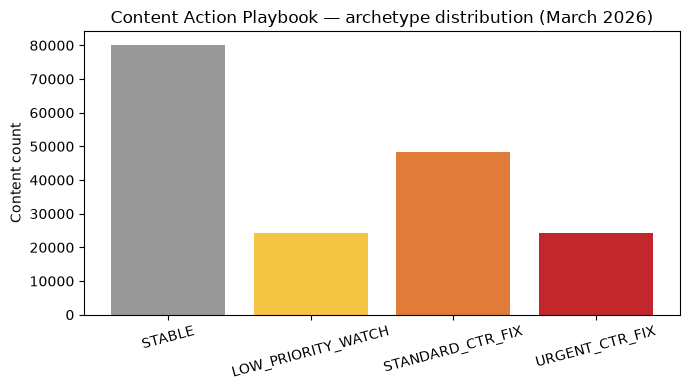

saved: work/figures/archetype_distribution.png


In [22]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(7, 4))
order = ["STABLE", "LOW_PRIORITY_WATCH", "STANDARD_CTR_FIX", "URGENT_CTR_FIX"]
counts = queue["archetype"].value_counts().reindex(order)
ax.bar(counts.index, counts.values, color=["#999999", "#f4c542", "#e07b39", "#c1272d"])
ax.set_ylabel("Content count")
ax.set_title("Content Action Playbook — archetype distribution (March 2026)")
plt.xticks(rotation=15)
plt.tight_layout()
plt.savefig("../figures/archetype_distribution.png", dpi=150)
plt.show()
print("saved: work/figures/archetype_distribution.png")

## Self-check

Before you submit, confirm each line honestly:

- [✅] Every section above is filled — markdown thinking AND the code that backs it
- [✅] The notebook runs top to bottom with no errors (Runtime → Run all)
- [✅] No client names, URLs, or private queries anywhere
- [✅] My claims use careful words: observed, measured, directional, decision-support
- [✅] Committed to my repo under `work/notebooks/` — then submit your repo URL on the card. Done.